In [ ]:
#Telecom companies lose customers due to churn.
#Goal: identify high-risk customers and understand why they leave.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [7]:
df=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [12]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df = df[df['TotalCharges'].notna()]

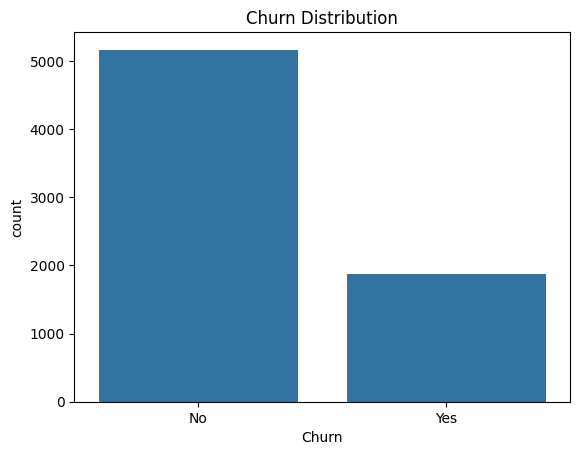

In [14]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

In [15]:
df['Churn'].value_counts()

,count
Churn,
No,5163
Yes,1869


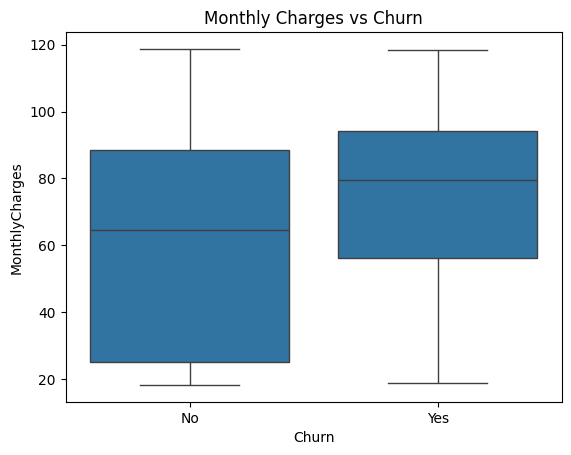

In [16]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### Insight

Monthly charges for churned customers are generally higher.  
No strong outliers are observed in the data.

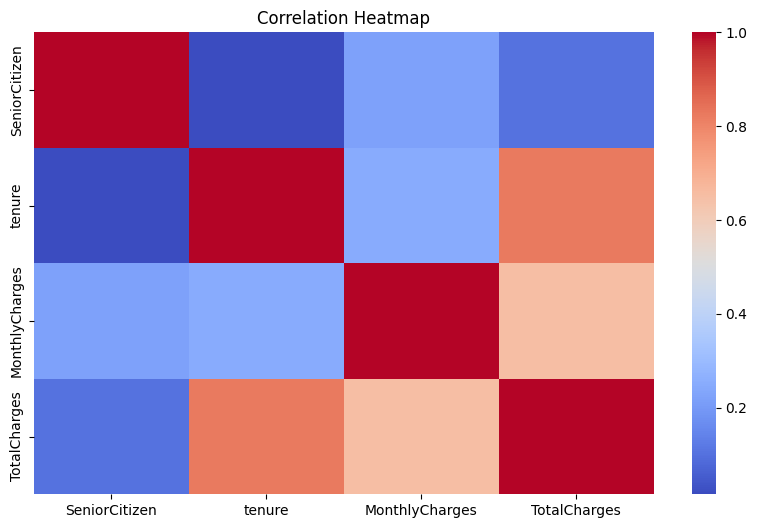

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [18]:
df.corr(numeric_only=True)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


In [19]:
df['ChargesPerMonth'] = df['TotalCharges'] / (df['tenure'] + 1)

In [20]:
df['IsNewCustomer'] = (df['tenure'] < 12).astype(int)
df['IsNewCustomer']

,IsNewCustomer
0,1
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,1
7041,1


In [22]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChargesPerMonth,IsNewCustomer,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,14.925000,1,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,53.985714,0,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,36.050000,1,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,40.016304,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,50.550000,1,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True


In [24]:
X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [28]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [29]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[962  71]
 [235 139]]


In [30]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

       False       0.80      0.93      0.86      1033
        True       0.66      0.37      0.48       374

    accuracy                           0.78      1407
   macro avg       0.73      0.65      0.67      1407
weighted avg       0.77      0.78      0.76      1407



In [31]:
roc_auc = roc_auc_score(y_test, y_prob)
print("\nROC-AUC Score:", roc_auc)


ROC-AUC Score: 0.82743268917177


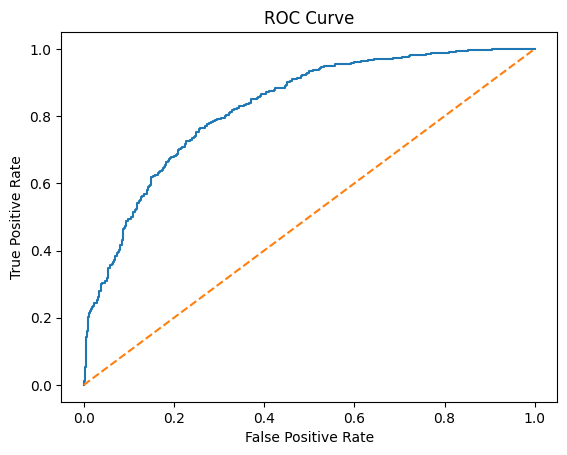

In [32]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [33]:
y_pred_new = (y_prob > 0.3).astype(int)

from sklearn.metrics import classification_report
print("After Threshold Tuning:\n")
print(classification_report(y_test, y_pred_new))

After Threshold Tuning:

              precision    recall  f1-score   support

       False       0.84      0.88      0.86      1033
        True       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [34]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest:

              precision    recall  f1-score   support

       False       0.82      0.91      0.86      1033
        True       0.65      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407



In [35]:
new_data_1 = pd.DataFrame({
    'tenure': [2],
    'MonthlyCharges': [90],
    'TotalCharges': [180],
    'SeniorCitizen': [0],
    'ChargesPerMonth': [180/(2+1)],
    'IsNewCustomer': [1]
})

In [36]:
new_data_2 = pd.DataFrame({
    'tenure': [12],
    'MonthlyCharges': [70],
    'TotalCharges': [840],
    'SeniorCitizen': [0],
    'ChargesPerMonth': [840/(12+1)],
    'IsNewCustomer': [0]
})

In [37]:
new_data_3 = pd.DataFrame({
    'tenure': [50],
    'MonthlyCharges': [40],
    'TotalCharges': [2000],
    'SeniorCitizen': [0],
    'ChargesPerMonth': [2000/(50+1)],
    'IsNewCustomer': [0]
})

In [39]:
new_data = new_data_1

In [43]:
new_data = new_data_3  # replace X with 1,2,3

# Align columns
new_data = new_data.reindex(columns=X.columns, fill_value=0)

# Scale
new_data_scaled = scaler.transform(new_data)

# Predict
prob = model.predict_proba(new_data_scaled)[:,1]
pred = (prob > 0.3).astype(int)

print("Churn Probability:", prob)
print("Prediction:", pred)

Churn Probability: [0.02070429]
Prediction: [0]


In [45]:
df_full = df.copy()
df_full.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChargesPerMonth,IsNewCustomer,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,14.925000,1,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,53.985714,0,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,36.050000,1,False,False,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,40.016304,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,50.550000,1,False,False,False,False,...,False,False,False,False,False,True,False,True,False,True


In [48]:
X_full = df_full.drop('Churn_Yes', axis=1)
X_full.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChargesPerMonth,IsNewCustomer,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,14.925000,1,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,53.985714,0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,36.050000,1,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,40.016304,0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,50.550000,1,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [49]:
X_full_scaled = scaler.transform(X_full)

In [50]:
df_full['Churn_Probability'] = model.predict_proba(X_full_scaled)[:,1]

In [51]:
df_full['Churn_Prediction'] = (df_full['Churn_Probability'] > 0.3).astype(int)

In [52]:
df_full['Churn_Prediction_Label'] = df_full['Churn_Prediction'].map({
    1: 'Churn',
    0: 'No Churn'
})

In [53]:
df_full.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChargesPerMonth,IsNewCustomer,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,Churn_Probability,Churn_Prediction,Churn_Prediction_Label
0,0,1,29.85,29.85,14.925000,1,False,False,False,False,...,False,False,True,False,True,False,False,0.001434,0,No Churn
1,0,34,56.95,1889.50,53.985714,0,False,False,False,False,...,True,False,False,False,False,True,False,0.000483,0,No Churn
2,0,2,53.85,108.15,36.050000,1,False,False,False,False,...,False,False,True,False,False,True,True,0.999209,1,Churn
3,0,45,42.30,1840.75,40.016304,0,False,False,False,False,...,True,False,False,False,False,False,False,0.000351,0,No Churn
4,0,2,70.70,151.65,50.550000,1,False,False,False,False,...,False,False,True,False,True,False,True,0.999517,1,Churn


In [54]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Columns: 7067 entries, SeniorCitizen to Churn_Prediction_Label
dtypes: bool(7058), float64(4), int64(4), object(1)
memory usage: 47.9+ MB


In [55]:
df_full['Churn_Prediction_Label'].value_counts()


,count
Churn_Prediction_Label,
No Churn,5221
Churn,1811


In [56]:
df_full.to_csv('churn_predictions.csv', index=False)